### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
from scipy.stats import median_abs_deviation
from tabulate import tabulate
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold

### Load the Datasets

In [2]:
#combined_df = pd.read_csv('combined_Octoparse_categorized.csv')
combined_df = pd.read_csv('..\..\Cleaned Data\Cleaned_Data_LastVersion.csv')
target_variable = 'Number of Reviewers'
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1854 entries, 0 to 1853
Data columns (total 48 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Business ID                               1854 non-null   object 
 1   Name                                      1854 non-null   object 
 2   Latitude                                  1854 non-null   float64
 3   Longitude                                 1854 non-null   float64
 4   Category                                  1854 non-null   object 
 5   Rating                                    1854 non-null   object 
 6   Popularity                                1854 non-null   float64
 7   Google Place ID                           1854 non-null   object 
 8   Business Status                           1854 non-null   object 
 9   Distance (m)                              1854 non-null   float64
 10  Cluster                             

## Data Pre-processing

### Drop Irrelevent columns

In [3]:
# Drop irrelevant columns
drop_columns = ['Business ID', 'Latitude'	, 'Longitude', 'Name', 'Category', 'Rating', 'Google Place ID', 'Business Status',
                'Cluster', 'Distance (m)', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 'Competition - Food & Dining/Area',
                'Competition - Business Type/POI Density', 'Competition - Food & Dining/related POIs', 'Competition - Business Type/related POIs'
               , 'Google Rating', 'Business Name']

combined_df.drop(columns=drop_columns, inplace=True, errors='ignore')


### Drop Rows with missing #of Reviewrs

In [4]:
# Ensure that the 'Number of Reviewers' column is numeric and handle errors as NaN
combined_df[target_variable] = pd.to_numeric(combined_df[target_variable], errors='coerce')

# Drop rows where 'Number of Reviewers' is NaN (if you want to ignore them in analysis)
combined_df = combined_df.dropna(subset=[target_variable])

### Fill Missing Values with median

In [6]:
print(combined_df.isnull().sum())

Popularity                                  0
generalCategory                             0
Religious Institutions                      0
Coffee Shops                                0
Food & Dining                               0
Restaurants                                 0
Home & Construction Services                0
Entertainment & Recreation                  0
Retail & Shopping                           0
Finance & Services                          0
Education                                   0
Health                                      0
Public & Government Services                0
Hotels & Hospitality                        0
Transportation & Travel                     0
Beauty & Wellness                           0
POI Density                                 0
Avg Rating - Food & Dining                 15
Competition - Food & Dining/POI Density     0
Population Within 1km                       0
Number of Reviewers                         0
Avg_NumOfReviewers - Food & Dining

In [5]:
#Fill missing values using median of the specfic food-chain

combined_df["Avg Rating - Food & Dining"] = combined_df["Avg Rating - Food & Dining"].fillna(combined_df["Avg Rating - Food & Dining"].median())
combined_df["Avg_NumOfReviewers - Food & Dining"] = combined_df["Avg_NumOfReviewers - Food & Dining"].fillna(combined_df["Avg_NumOfReviewers - Food & Dining"].median())
combined_df["Avg_NumOfReviewers_SameCategory"] = combined_df["Avg_NumOfReviewers_SameCategory"].fillna(combined_df["Avg_NumOfReviewers_SameCategory"].median())
combined_df["Total Num of Reviewers - Food & Dining"] = combined_df["Total Num of Reviewers - Food & Dining"].fillna(combined_df["Total Num of Reviewers - Food & Dining"].median())

print(combined_df.isnull().sum())

Popularity                                 0
generalCategory                            0
Religious Institutions                     0
Coffee Shops                               0
Food & Dining                              0
Restaurants                                0
Home & Construction Services               0
Entertainment & Recreation                 0
Retail & Shopping                          0
Finance & Services                         0
Education                                  0
Health                                     0
Public & Government Services               0
Hotels & Hospitality                       0
Transportation & Travel                    0
Beauty & Wellness                          0
POI Density                                0
Avg Rating - Food & Dining                 0
Competition - Food & Dining/POI Density    0
Population Within 1km                      0
Number of Reviewers                        0
Avg_NumOfReviewers - Food & Dining         0
Avg_NumOfR

In [8]:
combined_df.head()

,Popularity,generalCategory,Religious Institutions,Coffee Shops,Food & Dining,Restaurants,Home & Construction Services,Entertainment & Recreation,Retail & Shopping,Finance & Services,...,Number of Reviewers,Avg_NumOfReviewers - Food & Dining,Avg_NumOfReviewers_SameCategory,Population Within 2km,Population Within 3km,Total Num of Reviewers - Food & Dining,Total Num of Reviewers - All POIs,District,Residential Average Price,Avg Num of Reviewers - All POIs
0,0.968299,0,1,2,2,1,0,0,5,0,...,153.0,194.0,194.0,19724,61651,389.0,4050,Sinayiat Alfawaziya,39702.0,83.437500
1,0.991283,0,1,2,9,8,0,3,4,2,...,878.0,2357.0,453.0,53909,128780,21393.0,26379,Al Sahil,39702.0,566.847826
2,0.963778,0,3,1,4,3,0,0,3,2,...,29.0,2816.0,29.0,67458,158784,11293.0,14465,Iskan,22269.0,311.195652
3,0.943726,0,1,1,14,13,0,0,18,4,...,246.0,854.0,19.0,148696,253458,11966.0,17299,Al Thuqbah,13642.0,312.381818
4,0.544394,0,2,3,16,13,0,0,8,6,...,128.0,1379.0,492.0,155251,269213,22168.0,26715,Al Thuqbah,13642.0,492.074074


## Dataset Splitting

In [6]:
from sklearn.model_selection import train_test_split

# Get unique districts
districts = combined_df['District'].unique()

# Step 1: Split districts into 60% train and 40% temp (val + test)
train_districts, temp_districts = train_test_split(
    #combined_df
    districts,
    test_size=0.4,
    random_state=42,
    shuffle=True
)

# Step 2: Split the 40% temp into 20% val and 20% test
val_districts, test_districts = train_test_split(
    temp_districts,
    test_size=0.5,  # half of 40% = 20%
    random_state=42,
    shuffle=True
)

# Step 3: Create the actual data splits based on district labels
combined_df_train = combined_df[combined_df['District'].isin(train_districts)]
combined_df_val   = combined_df[combined_df['District'].isin(val_districts)]
combined_df_test  = combined_df[combined_df['District'].isin(test_districts)]

# Print summary
print(f"Train set size: {combined_df_train.shape[0]}")
print(f"Validation set size: {combined_df_val.shape[0]}")
print(f"Test set size: {combined_df_test.shape[0]}")


Train set size: 1090
Validation set size: 414
Test set size: 348


In [11]:
assert set(train_districts).isdisjoint(set(temp_districts)), "Train and test districts overlap!"

In [12]:
assert set(val_districts).isdisjoint(set(test_districts)), "Validation and test districts overlap!"

In [7]:
category_counts = combined_df_train['generalCategory'].value_counts()
print("Training df classes: \n",category_counts)

print("---")

category_counts = combined_df_val['generalCategory'].value_counts()
print("Validation df classes: \n",category_counts)

print("---")

category_counts = combined_df_test['generalCategory'].value_counts()
print("Test df classes: \n",category_counts)

Training df classes: 
 generalCategory
1    702
0    388
Name: count, dtype: int64
---
Validation df classes: 
 generalCategory
1    265
0    149
Name: count, dtype: int64
---
Test df classes: 
 generalCategory
1    218
0    130
Name: count, dtype: int64


### X and y Variables

In [8]:
# -----------------------------
# Step 1: Define features and target
# -----------------------------

columns_to_drop = [
    target_variable,
    'Total Num of Reviewers - Food & Dining',
    'Total Num of Reviewers - All POIs',
    'Avg_NumOfReviewers - Food & Dining',
    'Avg_NumOfReviewers_SameCategory',
    'Population Within 1km',
    'Population Within 2km',
    'Popularity',
    'District'
]

# Training set
X_train = combined_df_train.drop(columns=columns_to_drop, errors='ignore')
y_train = combined_df_train[target_variable]

# Validation set 
X_val = combined_df_val.drop(columns=columns_to_drop, errors='ignore')
y_val = combined_df_val[target_variable]

# Test set
X_test = combined_df_test.drop(columns=columns_to_drop, errors='ignore')
y_test = combined_df_test[target_variable].values

# Optional: Print summary
print(f"Train set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Train set size: 1090
Validation set size: 414
Test set size: 348


### Remove Highly Correlated features

In [9]:
# -----------------------------
# Step 2: Remove highly correlated features
# -----------------------------

def remove_highly_correlated_features(df, threshold=0.95):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

# Apply to training set
X_train, removed_corr_features = remove_highly_correlated_features(X_train, threshold=0.95)

# Ensure the same columns are removed from validation and test sets
X_val = X_val.drop(columns=removed_corr_features, errors='ignore')
X_test = X_test.drop(columns=removed_corr_features, errors='ignore')

# Store the final column list
X_columns = X_train.columns

# Print result
print(f"Removed highly correlated features: {removed_corr_features}")


Removed highly correlated features: ['Competition - Food & Dining/POI Density']


In [10]:
X_train.columns

Index(['generalCategory', 'Religious Institutions', 'Coffee Shops',
       'Food & Dining', 'Restaurants', 'Home & Construction Services',
       'Entertainment & Recreation', 'Retail & Shopping', 'Finance & Services',
       'Education', 'Health', 'Public & Government Services',
       'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness',
       'POI Density', 'Avg Rating - Food & Dining', 'Population Within 3km',
       'Residential Average Price', 'Avg Num of Reviewers - All POIs'],
      dtype='object')

In [11]:
X_val.columns

Index(['generalCategory', 'Religious Institutions', 'Coffee Shops',
       'Food & Dining', 'Restaurants', 'Home & Construction Services',
       'Entertainment & Recreation', 'Retail & Shopping', 'Finance & Services',
       'Education', 'Health', 'Public & Government Services',
       'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness',
       'POI Density', 'Avg Rating - Food & Dining', 'Population Within 3km',
       'Residential Average Price', 'Avg Num of Reviewers - All POIs'],
      dtype='object')

In [12]:
X_test.columns 

Index(['generalCategory', 'Religious Institutions', 'Coffee Shops',
       'Food & Dining', 'Restaurants', 'Home & Construction Services',
       'Entertainment & Recreation', 'Retail & Shopping', 'Finance & Services',
       'Education', 'Health', 'Public & Government Services',
       'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness',
       'POI Density', 'Avg Rating - Food & Dining', 'Population Within 3km',
       'Residential Average Price', 'Avg Num of Reviewers - All POIs'],
      dtype='object')

In [19]:
y_train

1        878.0
2         29.0
3        246.0
4        128.0
5        607.0
         ...  
1849      60.0
1850    2117.0
1851    1781.0
1852      95.0
1853      84.0
Name: Number of Reviewers, Length: 1090, dtype: float64

In [20]:
y_val

6        113.0
9        185.0
10       427.0
11       539.0
25       166.0
         ...  
1802     498.0
1813     264.0
1814     852.0
1833    2219.0
1843     699.0
Name: Number of Reviewers, Length: 414, dtype: float64

In [21]:
y_test

array([1.5300e+02, 4.7500e+02, 8.8500e+02, 1.6200e+02, 1.3440e+03,
       2.6200e+02, 7.4800e+02, 1.4100e+03, 5.8110e+03, 2.4310e+03,
       2.6700e+02, 3.0990e+03, 1.7920e+03, 1.3000e+01, 1.7170e+03,
       3.5000e+02, 1.1200e+03, 1.5870e+03, 1.6240e+03, 4.4100e+02,
       8.7100e+02, 8.4100e+02, 1.0320e+03, 1.2300e+02, 7.2800e+02,
       7.0000e+00, 1.3730e+03, 3.5500e+02, 6.2100e+02, 5.2800e+02,
       2.8600e+02, 8.4300e+02, 2.6800e+02, 5.0200e+02, 2.0020e+03,
       5.5100e+02, 1.2000e+02, 4.0400e+02, 8.3200e+02, 1.5780e+03,
       7.4000e+01, 2.2700e+02, 1.0990e+03, 2.7400e+02, 3.2750e+03,
       1.7390e+03, 4.8200e+02, 2.3280e+03, 1.7900e+02, 4.9100e+02,
       3.0100e+02, 1.5600e+02, 8.7000e+01, 1.1100e+02, 2.4000e+01,
       6.1000e+01, 3.2200e+02, 1.0500e+02, 4.6300e+02, 2.5800e+02,
       1.3330e+03, 4.8200e+02, 3.7800e+02, 8.9800e+02, 2.5600e+02,
       6.4100e+02, 1.0110e+03, 1.4200e+02, 2.0700e+02, 4.9300e+02,
       1.5800e+02, 3.8000e+01, 4.9500e+02, 7.4810e+03, 3.5800e

### Transformation and Scaling

In [13]:
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# -----------------------------
# Transform features (X)
# -----------------------------

# Initialize PowerTransformer and MinMaxScaler for X
pt = PowerTransformer(method='yeo-johnson', standardize=False)
scaler = MinMaxScaler()

# Fit only on training data
X_train_transformed = scaler.fit_transform(pt.fit_transform(X_train))

# Apply the same transformation to validation and test sets
X_val_transformed = scaler.transform(pt.transform(X_val))
X_test_transformed = scaler.transform(pt.transform(X_test))

# -----------------------------
# Transform target (y)
# -----------------------------

# Reshape y arrays
y_train_reshaped = y_train.values.reshape(-1, 1)
y_val_reshaped = y_val.values.reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

# Separate transformers for target
pt_y = PowerTransformer(method='yeo-johnson', standardize=False)
scaler_y = MinMaxScaler()

# Fit only on training target
y_train_transformed = scaler_y.fit_transform(pt_y.fit_transform(y_train_reshaped)).ravel()

# Transform validation and test targets using the same fit
y_val_transformed = scaler_y.transform(pt_y.transform(y_val_reshaped)).ravel()
y_test_transformed = scaler_y.transform(pt_y.transform(y_test_reshaped)).ravel()


# AI Models 

## Random Forest

### Baseline

In [23]:
# Print the column names before transformation
print(X_train.columns.tolist())


['generalCategory', 'Religious Institutions', 'Coffee Shops', 'Food & Dining', 'Restaurants', 'Home & Construction Services', 'Entertainment & Recreation', 'Retail & Shopping', 'Finance & Services', 'Education', 'Health', 'Public & Government Services', 'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness', 'POI Density', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']


In [24]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    ndcg_score, r2_score, mean_squared_error, mean_absolute_error
)

# Helper function
def compute_nsd(true_labels, pred_labels, k=10):
    true_top_k = set(np.argsort(true_labels)[::-1][:k])
    pred_top_k = set(np.argsort(pred_labels)[::-1][:k])
    symmetric_diff = true_top_k.symmetric_difference(pred_top_k)
    return len(symmetric_diff) / (2 * k)

# Hyperparameter grid
param_grid = {
    "n_estimators": [10, 50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt"]
}

# GridSearchCV on training data
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_transformed, y_train_transformed)

# Best model
best_model = grid.best_estimator_
print(f"\nBest Parameters: {grid.best_params_}")

# Predict on test set
y_test_pred = best_model.predict(X_test_transformed)

# --- Regression Metrics ---
r2 = r2_score(y_test_transformed, y_test_pred)
mse = mean_squared_error(y_test_transformed, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_transformed, y_test_pred)

# --- Ranking Metrics ---
k = 10
ndcg = ndcg_score([y_test_transformed], [y_test_pred], k=k)
nsd = compute_nsd(y_test_transformed, y_test_pred, k=k)

# --- Output ---
print("\n=== Final Test Set Evaluation ===")
print(f"R²:          {r2:.3f}")
print(f"MAE:         {mae:.3f}")
print(f"MSE:         {mse:.3f}")
print(f"RMSE:        {rmse:.3f}")
print(f"nDCG@10:     {ndcg:.3f}")
print(f"nSD@10:      {nsd:.3f}")



Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}

=== Final Test Set Evaluation ===
R²:          0.079
MAE:         0.122
MSE:         0.023
RMSE:        0.153
nDCG@10:     0.682
nSD@10:      0.800


### Recursive Feature Elimination (RFE) 

In [391]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ndcg_score
import pandas as pd
import numpy as np

def compute_nsd(true_labels, pred_labels, k=10):
    true_top_k = set(np.argsort(true_labels)[::-1][:k])
    pred_top_k = set(np.argsort(pred_labels)[::-1][:k])
    symmetric_diff = true_top_k.symmetric_difference(pred_top_k)
    return len(symmetric_diff) / (2 * k)

# Set your feature names list
feature_names = X_train.columns.tolist()

results = []
feature_counts = [11, 9, 7, 5]

param_grid = {
    "n_estimators": [10, 50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt"]
}

for n in feature_counts:
    print(f"\n>>> Running RFE with top {n} features...")

    # RFE on training set only
    rf = RandomForestRegressor(random_state=42)
    rfe = RFE(estimator=rf, n_features_to_select=n)
    rfe.fit(X_train_transformed, y_train_transformed)

    selected_indices = np.where(rfe.support_)[0]
    selected_features = [feature_names[i] for i in selected_indices]
    print(f"Selected Features: {selected_features}")

    # Apply selected features to all sets
    x_train_selected = X_train_transformed[:, selected_indices]
    x_val_selected = X_val_transformed[:, selected_indices]
    x_test_selected = X_test_transformed[:, selected_indices]  # still kept for future use

    # GridSearch on training, evaluated via cross-validation
    grid = GridSearchCV(
        RandomForestRegressor(random_state=42),
        param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )
    
    grid.fit(x_train_selected, y_train_transformed)

    # Predict on validation set only
    y_val_pred = grid.predict(x_val_selected)

    # Ranking metrics on validation
    ndcg = ndcg_score([y_val_transformed], [y_val_pred], k=10)
    nsd = compute_nsd(y_val_transformed, y_val_pred, k=10)

    print(f"nDCG@10 (val): {ndcg:.3f}")
    print(f"nSD@10 (val):  {nsd:.3f}")
    print(f"Best Params: {grid.best_params_}")

    # Store results
    results.append({
        'n_features': n,
        'selected_features': selected_features,
        'nDCG@10_val': ndcg,
        'nSD@10_val': nsd,
        'best_params': grid.best_params_
    })

# Summary DataFrame
df_results = pd.DataFrame(results)
print("\n=== Summary ===")
print(df_results)



>>> Running RFE with top 11 features...
Selected Features: ['generalCategory', 'Coffee Shops', 'Food & Dining', 'Restaurants', 'Retail & Shopping', 'Finance & Services', 'Hotels & Hospitality', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']
nDCG@10 (val): 0.741
nSD@10 (val):  0.700
Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

>>> Running RFE with top 9 features...
Selected Features: ['generalCategory', 'Food & Dining', 'Restaurants', 'Retail & Shopping', 'Hotels & Hospitality', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']
nDCG@10 (val): 0.610
nSD@10 (val):  0.900
Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

>>> Running RFE with top 7 features...
Selected Features: ['generalCategory', '

### Features Importance

### Average 10 runs

#### 11 Features

In [292]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score

# Use the best feature set and parameters determined from validation
selected_columns = ['generalCategory', 'Coffee Shops', 'Food & Dining', 'Restaurants', 'Retail & Shopping', 'Finance & Services', 'Hotels & Hospitality', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']

selected_indices = [X_train.columns.get_loc(col) for col in selected_columns]

X_train_selected = X_train_transformed[:, selected_indices]
X_test_selected = X_test_transformed[:, selected_indices]

results = []

for run in range(10):
    # Instantiate the model with best-found parameters
    rf_model = RandomForestRegressor(
        random_state=None,
        max_depth=10,
        max_features='sqrt',
        min_samples_leaf=2,
        min_samples_split=5,
        n_estimators=200
    )
    
    rf_model.fit(X_train_selected, y_train_transformed)
    y_pred = rf_model.predict(X_test_selected)

    # Regression metrics
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # Ranking metrics
    k = 10
    true_ranks = y_test_transformed.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]

    true_relevance = np.expand_dims(y_test_transformed, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD,
    })

# --- Summary Report ---
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Runs (Test Set) ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))

print("Last run:")
print('top_k_true', top_k_true)
print('top_k_pred', top_k_pred)



==================== Summary of 10 Runs (Test Set) ====================
   run        r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  0.118820  0.022461  0.149871  0.118530  0.624302     0.8
1    2  0.107385  0.022753  0.150841  0.118963  0.613698     0.8
2    3  0.116150  0.022530  0.150098  0.118518  0.617051     0.8
3    4  0.125298  0.022296  0.149320  0.117935  0.636283     0.8
4    5  0.121542  0.022392  0.149640  0.118401  0.623281     0.8
5    6  0.127392  0.022243  0.149141  0.117438  0.644434     0.8
6    7  0.122259  0.022374  0.149579  0.117974  0.671134     0.8
7    8  0.118044  0.022481  0.149938  0.118340  0.708121     0.8
8    9  0.134040  0.022074  0.148572  0.117844  0.646118     0.8
9   10  0.109465  0.022700  0.150665  0.118783  0.626242     0.8

=== Average Metrics Across 10 Runs ===
r2         0.120
mse        0.022
rmse       0.150
mae        0.118
ndcg@10    0.641
nSD@10     0.800
dtype: float64
Last run:
top_k_true {165, 262, 263, 8, 73, 172, 146, 3

#### 9 Features

In [294]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score

# Use the best feature set and parameters determined from validation
selected_columns = ['generalCategory', 'Food & Dining', 'Restaurants', 'Retail & Shopping', 'Hotels & Hospitality', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']

selected_indices = [X_train.columns.get_loc(col) for col in selected_columns]

X_train_selected = X_train_transformed[:, selected_indices]
X_test_selected = X_test_transformed[:, selected_indices]

results = []

for run in range(10):
    # Instantiate the model with best-found parameters
    rf_model = RandomForestRegressor(
        random_state=None,
        max_depth=20,
        max_features='sqrt',
        min_samples_leaf=4,
        min_samples_split=10,
        n_estimators=200
    )

    rf_model.fit(X_train_selected, y_train_transformed)
    y_pred = rf_model.predict(X_test_selected)

    # Regression metrics
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # Ranking metrics
    k = 10
    true_ranks = y_test_transformed.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]

    true_relevance = np.expand_dims(y_test_transformed, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD,
    })

# --- Summary Report ---
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Runs (Test Set) ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))

print("Last run:")
print('top_k_true', top_k_true)
print('top_k_pred', top_k_pred)



==================== Summary of 10 Runs (Test Set) ====================
   run        r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  0.137415  0.021987  0.148282  0.116415  0.604764     0.9
1    2  0.130483  0.022164  0.148876  0.116769  0.587681     0.8
2    3  0.125905  0.022281  0.149268  0.117002  0.578530     1.0
3    4  0.129593  0.022187  0.148953  0.116471  0.576132     1.0
4    5  0.132971  0.022101  0.148663  0.116743  0.610936     0.9
5    6  0.135335  0.022040  0.148460  0.116208  0.624421     0.8
6    7  0.125412  0.022293  0.149310  0.117447  0.566488     0.8
7    8  0.131191  0.022146  0.148816  0.116718  0.641162     0.8
8    9  0.134383  0.022065  0.148542  0.116507  0.628895     0.8
9   10  0.135169  0.022045  0.148475  0.116220  0.630418     0.9

=== Average Metrics Across 10 Runs ===
r2         0.132
mse        0.022
rmse       0.149
mae        0.117
ndcg@10    0.605
nSD@10     0.870
dtype: float64
Last run:
top_k_true {165, 262, 263, 8, 73, 172, 146, 3

#### 7 Features

In [296]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score

# Use the best feature set and parameters determined from validation
selected_columns = ['generalCategory', 'Food & Dining', 'Retail & Shopping', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']
selected_indices = [X_train.columns.get_loc(col) for col in selected_columns]

X_train_selected = X_train_transformed[:, selected_indices]
X_test_selected = X_test_transformed[:, selected_indices]

results = []

for run in range(10):
    # Instantiate the model with best-found parameters
    rf_model = RandomForestRegressor(
        random_state=None,
        max_depth=10,
        max_features='sqrt',
        min_samples_leaf=2,
        min_samples_split=10,
        n_estimators=200
    )

    rf_model.fit(X_train_selected, y_train_transformed)
    y_pred = rf_model.predict(X_test_selected)

    # Regression metrics
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # Ranking metrics
    k = 10
    true_ranks = y_test_transformed.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]

    true_relevance = np.expand_dims(y_test_transformed, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD,
    })

# --- Summary Report ---
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Runs (Test Set) ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))

print("Last run:")
print('top_k_true', top_k_true)
print('top_k_pred', top_k_pred)



==================== Summary of 10 Runs (Test Set) ====================
   run        r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  0.123085  0.022353  0.149508  0.117300  0.543131     1.0
1    2  0.129831  0.022181  0.148932  0.116354  0.558256     0.9
2    3  0.122833  0.022359  0.149530  0.117413  0.521517     1.0
3    4  0.130009  0.022176  0.148917  0.116811  0.605581     1.0
4    5  0.129219  0.022196  0.148985  0.116889  0.530728     0.9
5    6  0.136241  0.022017  0.148383  0.116060  0.586012     1.0
6    7  0.121545  0.022392  0.149640  0.117053  0.558474     1.0
7    8  0.123461  0.022343  0.149476  0.117233  0.540142     1.0
8    9  0.128339  0.022219  0.149060  0.116470  0.547679     1.0
9   10  0.128794  0.022207  0.149021  0.116927  0.594600     1.0

=== Average Metrics Across 10 Runs ===
r2         0.127
mse        0.022
rmse       0.149
mae        0.117
ndcg@10    0.559
nSD@10     0.980
dtype: float64
Last run:
top_k_true {165, 262, 263, 8, 73, 172, 146, 3

#### 5 Features

In [300]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score

# Use the best feature set and parameters determined from validation
selected_columns = ['Food & Dining', 'Retail & Shopping', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Avg Num of Reviewers - All POIs']
selected_indices = [X_train.columns.get_loc(col) for col in selected_columns]

X_train_selected = X_train_transformed[:, selected_indices]
X_test_selected = X_test_transformed[:, selected_indices]

results = []

for run in range(10):
    # Instantiate the model with best-found parameters
    rf_model = RandomForestRegressor(
        random_state=None,
        max_depth=10,
        max_features='sqrt',
        min_samples_leaf=4,
        min_samples_split=10,
        n_estimators=200
    )

    rf_model.fit(X_train_selected, y_train_transformed)
    y_pred = rf_model.predict(X_test_selected)

    # Regression metrics
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # Ranking metrics
    k = 10
    true_ranks = y_test_transformed.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]

    true_relevance = np.expand_dims(y_test_transformed, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD,
    })

# --- Summary Report ---
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Runs (Test Set) ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))

print("Last run:")
print('top_k_true', top_k_true)
print('top_k_pred', top_k_pred)



==================== Summary of 10 Runs (Test Set) ====================
   run        r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  0.018816  0.025011  0.158147  0.123297  0.536933     1.0
1    2  0.023536  0.024890  0.157766  0.123136  0.496909     1.0
2    3  0.011147  0.025206  0.158764  0.123942  0.503200     1.0
3    4  0.015945  0.025084  0.158379  0.123724  0.544848     1.0
4    5  0.019943  0.024982  0.158056  0.123469  0.483447     1.0
5    6  0.015682  0.025090  0.158400  0.123534  0.487767     1.0
6    7  0.015256  0.025101  0.158434  0.123434  0.486801     1.0
7    8  0.011485  0.025197  0.158737  0.123994  0.535676     1.0
8    9  0.014153  0.025129  0.158523  0.123521  0.480711     1.0
9   10  0.016528  0.025069  0.158332  0.123794  0.533601     1.0

=== Average Metrics Across 10 Runs ===
r2         0.016
mse        0.025
rmse       0.158
mae        0.124
ndcg@10    0.509
nSD@10     1.000
dtype: float64
Last run:
top_k_true {165, 262, 263, 8, 73, 172, 146, 3

## XGBoost

### Baseline

In [302]:
# Print the column names before transformation
print(X_train.columns.tolist())


['generalCategory', 'Religious Institutions', 'Coffee Shops', 'Food & Dining', 'Restaurants', 'Home & Construction Services', 'Entertainment & Recreation', 'Retail & Shopping', 'Finance & Services', 'Education', 'Health', 'Public & Government Services', 'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness', 'POI Density', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']


In [304]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    ndcg_score, r2_score, mean_squared_error, mean_absolute_error
)

# Helper function
def compute_nsd(true_labels, pred_labels, k=10):
    true_top_k = set(np.argsort(true_labels)[::-1][:k])
    pred_top_k = set(np.argsort(pred_labels)[::-1][:k])
    symmetric_diff = true_top_k.symmetric_difference(pred_top_k)
    return len(symmetric_diff) / (2 * k)

# XGBoost hyperparameter grid
param_grid = {
    "n_estimators": [10, 50, 100, 200],
    "max_depth": [3, 5, 10],  # smaller values preferred for boosting
    "learning_rate": [0.01, 0.1, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# GridSearchCV using XGBRegressor
grid = GridSearchCV(
    estimator=XGBRegressor(
        objective='reg:squarederror',  # required for regression in XGBoost
        random_state=42,
        verbosity=0
    ),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train and tune on training data
grid.fit(X_train_transformed, y_train_transformed)

# Best model
best_model = grid.best_estimator_
print(f"\nBest Parameters: {grid.best_params_}")

# Predict on test set
y_test_pred = best_model.predict(X_test_transformed)

# --- Regression Metrics ---
r2 = r2_score(y_test_transformed, y_test_pred)
mse = mean_squared_error(y_test_transformed, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_transformed, y_test_pred)

# --- Ranking Metrics ---
k = 10
ndcg = ndcg_score([y_test_transformed], [y_test_pred], k=k)
nsd = compute_nsd(y_test_transformed, y_test_pred, k=k)

# --- Output ---
print("\n=== Final Test Set Evaluation ===")
print(f"R²:          {r2:.3f}")
print(f"MAE:         {mae:.3f}")
print(f"MSE:         {mse:.3f}")
print(f"RMSE:        {rmse:.3f}")
print(f"nDCG@10:     {ndcg:.3f}")
print(f"nSD@10:      {nsd:.3f}")



Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}

=== Final Test Set Evaluation ===
R²:          0.108
MAE:         0.120
MSE:         0.023
RMSE:        0.151
nDCG@10:     0.623
nSD@10:      0.900


### RFE For XGBoost

In [306]:
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ndcg_score
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

def compute_nsd(true_labels, pred_labels, k=10):
    true_top_k = set(np.argsort(true_labels)[::-1][:k])
    pred_top_k = set(np.argsort(pred_labels)[::-1][:k])
    symmetric_diff = true_top_k.symmetric_difference(pred_top_k)
    return len(symmetric_diff) / (2 * k)

# Get feature names before transformation
feature_names = X_train.columns.tolist()

# Feature counts to evaluate
feature_counts = [11, 9, 7, 5]

# Hyperparameter grid for XGBoost
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Results container
results = []

# Loop over different numbers of selected features
for n in feature_counts:
    print(f"\n>>> Running RFE with top {n} features...")

    # Use XGBoost for RFE
    xgb_base = XGBRegressor(objective='reg:squarederror', random_state=42)
    rfe = RFE(estimator=xgb_base, n_features_to_select=n)
    rfe.fit(X_train_transformed, y_train_transformed)

    # Get selected feature indices and names
    selected_indices = np.where(rfe.support_)[0]
    selected_features = [feature_names[i] for i in selected_indices]
    print(f"Selected Features: {selected_features}")

    # Subset data with selected features
    x_train_selected = X_train_transformed[:, selected_indices]
    x_val_selected = X_val_transformed[:, selected_indices]

    # GridSearchCV for XGBoost
    grid = GridSearchCV(
        estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
        param_grid=param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    grid.fit(x_train_selected, y_train_transformed)

    # Predict on validation set
    y_val_pred = grid.predict(x_val_selected)

    # Ranking metrics on validation
    ndcg = ndcg_score([y_val_transformed], [y_val_pred], k=10)
    nsd = compute_nsd(y_val_transformed, y_val_pred, k=10)

    print(f"nDCG@10 (val): {ndcg:.3f}")
    print(f"nSD@10  (val): {nsd:.3f}")
    print(f"Best Params: {grid.best_params_}")

    results.append({
        'n_features': n,
        'selected_features': selected_features,
        'nDCG@10_val': ndcg,
        'nSD@10_val': nsd,
        'best_params': grid.best_params_
    })

# Summary results
df_results = pd.DataFrame(results)
print("\n=== Summary ===")
print(df_results)


>>> Running RFE with top 11 features...
Selected Features: ['generalCategory', 'Entertainment & Recreation', 'Retail & Shopping', 'Public & Government Services', 'Transportation & Travel', 'Beauty & Wellness', 'POI Density', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']
nDCG@10 (val): 0.763
nSD@10  (val): 0.800
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}

>>> Running RFE with top 9 features...
Selected Features: ['generalCategory', 'Entertainment & Recreation', 'Public & Government Services', 'Beauty & Wellness', 'POI Density', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']
nDCG@10 (val): 0.811
nSD@10  (val): 0.800
Best Params: {'colsample_bytree': 1, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

>>> Running RFE with top 7 features...
Selec

### AVG 10 Runs 

#### 11 Features 

In [308]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, ndcg_score
)
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Columns selected for modeling
selected_columns = ['generalCategory', 'Entertainment & Recreation', 'Retail & Shopping', 'Public & Government Services', 'Transportation & Travel', 'Beauty & Wellness', 'POI Density', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']
selected_indices = [X_train.columns.get_loc(col) for col in selected_columns]

# Subset features from transformed training and testing sets
X_train_selected = X_train_transformed[:, selected_indices]
X_test_selected = X_test_transformed[:, selected_indices]

# Container to hold results for each run
results = []

# Run experiment 10 times
for run in range(10):
    # Define XGBoost model
    xgb_model = XGBRegressor(
        objective='reg:squarederror',
        random_state=None,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        n_estimators=50
    )
    
    # Train model
    xgb_model.fit(X_train_selected, y_train_transformed)
    
    # Predict on test set
    y_pred = xgb_model.predict(X_test_selected)

    # -----------------------------
    # Regression Metrics
    # -----------------------------
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # -----------------------------
    # Ranking Metrics
    # -----------------------------
    k = 10
    true_ranks = y_test_transformed.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]

    true_relevance = np.expand_dims(y_test_transformed, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    # Save run results
    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD,
    })

# -----------------------------
# Summary Report
# -----------------------------
results_df = pd.DataFrame(results)

print("\n==================== Summary of 10 Runs ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))

print("Last run:")
print('top_k_true', top_k_true)
print('top_k_pred', top_k_pred)



==================== Summary of 10 Runs ====================
   run        r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  0.134745  0.022056  0.148511  0.118263  0.611883     0.8
1    2  0.134745  0.022056  0.148511  0.118263  0.611883     0.8
2    3  0.134745  0.022056  0.148511  0.118263  0.611883     0.8
3    4  0.134745  0.022056  0.148511  0.118263  0.611883     0.8
4    5  0.134745  0.022056  0.148511  0.118263  0.611883     0.8
5    6  0.134745  0.022056  0.148511  0.118263  0.611883     0.8
6    7  0.134745  0.022056  0.148511  0.118263  0.611883     0.8
7    8  0.134745  0.022056  0.148511  0.118263  0.611883     0.8
8    9  0.134745  0.022056  0.148511  0.118263  0.611883     0.8
9   10  0.134745  0.022056  0.148511  0.118263  0.611883     0.8

=== Average Metrics Across 10 Runs ===
r2         0.135
mse        0.022
rmse       0.149
mae        0.118
ndcg@10    0.612
nSD@10     0.800
dtype: float64
Last run:
top_k_true {165, 262, 263, 8, 73, 172, 146, 340, 281, 22

#### 9 Features 

In [310]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, ndcg_score
)
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Columns selected for modeling
selected_columns = ['generalCategory', 'Entertainment & Recreation', 'Public & Government Services', 'Beauty & Wellness', 'POI Density', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']

# Subset features from transformed training and testing sets
X_train_selected = X_train_transformed[:, selected_indices]
X_test_selected = X_test_transformed[:, selected_indices]

# Container to hold results for each run
results = []

# Run experiment 10 times
for run in range(10):
    # Define XGBoost model
    xgb_model = XGBRegressor(
        objective='reg:squarederror',
        random_state=None,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=1,
        n_estimators=200
    )
    
    # Train model
    xgb_model.fit(X_train_selected, y_train_transformed)
    
    # Predict on test set
    y_pred = xgb_model.predict(X_test_selected)

    # -----------------------------
    # Regression Metrics
    # -----------------------------
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # -----------------------------
    # Ranking Metrics
    # -----------------------------
    k = 10
    true_ranks = y_test_transformed.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]

    true_relevance = np.expand_dims(y_test_transformed, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    # Save run results
    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD,
    })

# -----------------------------
# Summary Report
# -----------------------------
results_df = pd.DataFrame(results)

print("\n==================== Summary of 10 Runs ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))

print("Last run:")
print('top_k_true', top_k_true)
print('top_k_pred', top_k_pred)



==================== Summary of 10 Runs ====================
   run        r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  0.133293  0.022093  0.148636  0.117907  0.712943     0.7
1    2  0.133293  0.022093  0.148636  0.117907  0.712943     0.7
2    3  0.133293  0.022093  0.148636  0.117907  0.712943     0.7
3    4  0.133293  0.022093  0.148636  0.117907  0.712943     0.7
4    5  0.133293  0.022093  0.148636  0.117907  0.712943     0.7
5    6  0.133293  0.022093  0.148636  0.117907  0.712943     0.7
6    7  0.133293  0.022093  0.148636  0.117907  0.712943     0.7
7    8  0.133293  0.022093  0.148636  0.117907  0.712943     0.7
8    9  0.133293  0.022093  0.148636  0.117907  0.712943     0.7
9   10  0.133293  0.022093  0.148636  0.117907  0.712943     0.7

=== Average Metrics Across 10 Runs ===
r2         0.133
mse        0.022
rmse       0.149
mae        0.118
ndcg@10    0.713
nSD@10     0.700
dtype: float64
Last run:
top_k_true {165, 262, 263, 8, 73, 172, 146, 340, 281, 22

#### 7 Features 

In [312]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, ndcg_score
)
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Columns selected for modeling
selected_columns = ['generalCategory', 'Entertainment & Recreation', 'Beauty & Wellness', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']
selected_indices = [X_train.columns.get_loc(col) for col in selected_columns]

# Subset features from transformed training and testing sets
X_train_selected = X_train_transformed[:, selected_indices]
X_test_selected = X_test_transformed[:, selected_indices]

# Container to hold results for each run
results = []

# Run experiment 10 times
for run in range(10):
    # Define XGBoost model
    xgb_model = XGBRegressor(
        objective='reg:squarederror',
        random_state=None,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=1,
        n_estimators=50
    )

    # Train model
    xgb_model.fit(X_train_selected, y_train_transformed)
    
    # Predict on test set
    y_pred = xgb_model.predict(X_test_selected)

    # -----------------------------
    # Regression Metrics
    # -----------------------------
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # -----------------------------
    # Ranking Metrics
    # -----------------------------
    k = 10
    true_ranks = y_test_transformed.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]
    
    true_relevance = np.expand_dims(y_test_transformed, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    # Save run results
    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD,
    })

# -----------------------------
# Summary Report
# -----------------------------
results_df = pd.DataFrame(results)

print("\n==================== Summary of 10 Runs ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))

print("Last run:")
print('top_k_true', top_k_true)
print('top_k_pred', top_k_pred)



==================== Summary of 10 Runs ====================
   run        r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  0.113113  0.022607  0.150356  0.118673  0.674464     0.7
1    2  0.113113  0.022607  0.150356  0.118673  0.674464     0.7
2    3  0.113113  0.022607  0.150356  0.118673  0.674464     0.7
3    4  0.113113  0.022607  0.150356  0.118673  0.674464     0.7
4    5  0.113113  0.022607  0.150356  0.118673  0.674464     0.7
5    6  0.113113  0.022607  0.150356  0.118673  0.674464     0.7
6    7  0.113113  0.022607  0.150356  0.118673  0.674464     0.7
7    8  0.113113  0.022607  0.150356  0.118673  0.674464     0.7
8    9  0.113113  0.022607  0.150356  0.118673  0.674464     0.7
9   10  0.113113  0.022607  0.150356  0.118673  0.674464     0.7

=== Average Metrics Across 10 Runs ===
r2         0.113
mse        0.023
rmse       0.150
mae        0.119
ndcg@10    0.674
nSD@10     0.700
dtype: float64
Last run:
top_k_true {165, 262, 263, 8, 73, 172, 146, 340, 281, 22

#### 5 Features 

In [314]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, ndcg_score
)
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Columns selected for modeling
selected_columns = ['generalCategory', 'Entertainment & Recreation', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']
selected_indices = [X_train.columns.get_loc(col) for col in selected_columns]

# Subset features from transformed training and testing sets
X_train_selected = X_train_transformed[:, selected_indices]
X_test_selected = X_test_transformed[:, selected_indices]

# Container to hold results for each run
results = []

# Run experiment 10 times
for run in range(10):
    # Define XGBoost model
    xgb_model = XGBRegressor(
        objective='reg:squarederror',
        random_state=None,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=1,
        n_estimators=50
    )

    # Train model
    xgb_model.fit(X_train_selected, y_train_transformed)
    
    # Predict on test set
    y_pred = xgb_model.predict(X_test_selected)

    # -----------------------------
    # Regression Metrics
    # -----------------------------
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # -----------------------------
    # Ranking Metrics
    # -----------------------------
    k = 10
    true_ranks = y_test_transformed.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]

    true_relevance = np.expand_dims(y_test_transformed, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    # Save run results
    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD,
    })

# -----------------------------
# Summary Report
# -----------------------------
results_df = pd.DataFrame(results)

print("\n==================== Summary of 10 Runs ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))

print("Last run:")
print('top_k_true', top_k_true)
print('top_k_pred', top_k_pred)



==================== Summary of 10 Runs ====================
   run       r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  0.10522  0.022808  0.151024  0.118356  0.632632     1.0
1    2  0.10522  0.022808  0.151024  0.118356  0.632632     1.0
2    3  0.10522  0.022808  0.151024  0.118356  0.632632     1.0
3    4  0.10522  0.022808  0.151024  0.118356  0.632632     1.0
4    5  0.10522  0.022808  0.151024  0.118356  0.632632     1.0
5    6  0.10522  0.022808  0.151024  0.118356  0.632632     1.0
6    7  0.10522  0.022808  0.151024  0.118356  0.632632     1.0
7    8  0.10522  0.022808  0.151024  0.118356  0.632632     1.0
8    9  0.10522  0.022808  0.151024  0.118356  0.632632     1.0
9   10  0.10522  0.022808  0.151024  0.118356  0.632632     1.0

=== Average Metrics Across 10 Runs ===
r2         0.105
mse        0.023
rmse       0.151
mae        0.118
ndcg@10    0.633
nSD@10     1.000
dtype: float64
Last run:
top_k_true {165, 262, 263, 8, 73, 172, 146, 340, 281, 222}
top_k_pr

### Exhaustive Feature Selection (EFS)

In [125]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

results = []

feature_counts = [5, 7, 9, 11]
X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=X_test.columns)

for n in feature_counts:
    print(f"\n>>> Running Exhaustive Feature Selection with top {n} features...")

    xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

    efs = EFS(
        estimator=xgb_model,
        min_features=n,
        max_features=n,
        scoring='r2',
        print_progress=True,
        cv=5,
        n_jobs=-1
    )

    efs.fit(X_train_transformed, y_train_transformed)

    selected_features = list(efs.best_feature_names_)
    print(f"Selected Features: {selected_features}")

    # GridSearch for best hyperparameters
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 6, 10],
        'learning_rate': [0.01, 0.1, 0.2, 0.3],
        'subsample': [0.8, 1],
        'colsample_bytree': [0.8, 1]
    }

    grid_search = GridSearchCV(
        XGBRegressor(objective='reg:squarederror', random_state=42),
        param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    grid_search.fit(X_train_transformed[selected_features], y_train_transformed)

    best_params = grid_search.best_params_
    print(f"Best Parameters: {best_params}")

    y_pred = grid_search.best_estimator_.predict(X_test_transformed[selected_features])

    # Regression Metrics
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # Ranking Metrics
    k = 10
    true_relevance = np.expand_dims(y_test_transformed, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    true_ranks = y_test_transformed.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]
    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    avg_metrics = {
        'n_features': n,
        'r2': round(r2, 3),
        'mse': round(mse, 3),
        'rmse': round(rmse, 3),
        'mae': round(mae, 3),
        f'ndcg@{k}': round(ndcg, 3),
        f'nSD@{k}': round(nSD, 3),
        'selected_features': selected_features,
        'best_params': best_params
    }

    print("\n=== Metrics ===")
    print(avg_metrics)

    results.append(avg_metrics)

df_results = pd.DataFrame(results)

# Summary
print("\n=== Summary ===")
print(df_results)


>>> Running Exhaustive Feature Selection with top 5 features...


Features: 15504/15504

Selected Features: ['generalCategory', 'Retail & Shopping', 'Beauty & Wellness', 'Population Within 3km', 'Avg Num of Reviewers - All POIs']
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}

=== Metrics ===
{'n_features': 5, 'r2': 0.215, 'mse': 0.021, 'rmse': 0.144, 'mae': 0.113, 'ndcg@10': 0.764, 'nSD@10': 0.7, 'selected_features': ['generalCategory', 'Retail & Shopping', 'Beauty & Wellness', 'Population Within 3km', 'Avg Num of Reviewers - All POIs'], 'best_params': {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}}

>>> Running Exhaustive Feature Selection with top 7 features...


Features: 77520/77520

Selected Features: ['generalCategory', 'Home & Construction Services', 'Retail & Shopping', 'Finance & Services', 'Beauty & Wellness', 'Population Within 3km', 'Avg Num of Reviewers - All POIs']


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}

=== Metrics ===
{'n_features': 7, 'r2': 0.214, 'mse': 0.021, 'rmse': 0.144, 'mae': 0.113, 'ndcg@10': 0.771, 'nSD@10': 0.7, 'selected_features': ['generalCategory', 'Home & Construction Services', 'Retail & Shopping', 'Finance & Services', 'Beauty & Wellness', 'Population Within 3km', 'Avg Num of Reviewers - All POIs'], 'best_params': {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}}

>>> Running Exhaustive Feature Selection with top 9 features...


## SVR 

### Baseline

In [318]:
# Print the column names before transformation
print(X_train.columns.tolist())


['generalCategory', 'Religious Institutions', 'Coffee Shops', 'Food & Dining', 'Restaurants', 'Home & Construction Services', 'Entertainment & Recreation', 'Retail & Shopping', 'Finance & Services', 'Education', 'Health', 'Public & Government Services', 'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness', 'POI Density', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']


In [15]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    ndcg_score, r2_score, mean_squared_error, mean_absolute_error
)

# --- Helper function for ranking ---
def compute_nsd(true_labels, pred_labels, k=10):
    true_top_k = set(np.argsort(true_labels)[::-1][:k])
    pred_top_k = set(np.argsort(pred_labels)[::-1][:k])
    return len(true_top_k.symmetric_difference(pred_top_k)) / (2 * k)

# --- Corrected hyperparameter grid (no 'svr__' prefix) ---
param_grid = {
    "kernel": ['linear', 'rbf', 'sigmoid'],
    "C": [0.1, 1, 10, 100],
    "gamma": ['scale', 0.01, 0.001, 0.1, 0.2, 0.3],
    "epsilon": [0.01, 0.1, 0.2]
}

# --- GridSearchCV using SVR ---
grid = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# --- Fit on training data ---
grid.fit(X_train_transformed, y_train_transformed)

# --- Predict on test set ---
best_model = grid.best_estimator_
print("\nBest Parameters:", grid.best_params_)

y_test_pred = best_model.predict(X_test_transformed)

# --- Regression Metrics ---
r2 = r2_score(y_test_transformed, y_test_pred)
mse = mean_squared_error(y_test_transformed, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_transformed, y_test_pred)

# --- Ranking Metrics ---
k = 10
ndcg = ndcg_score([y_test_transformed], [y_test_pred], k=k)
nsd = compute_nsd(y_test_transformed, y_test_pred, k=k)

# --- Output ---
print("\n=== Final Test Set Evaluation (SVR) ===")
print(f"R²:          {r2:.3f}")
print(f"MAE:         {mae:.3f}")
print(f"MSE:         {mse:.3f}")
print(f"RMSE:        {rmse:.3f}")
print(f"nDCG@10:     {ndcg:.3f}")
print(f"nSD@10:      {nsd:.3f}")



Best Parameters: {'C': 10, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}

=== Final Test Set Evaluation (SVR) ===
R²:          0.094
MAE:         0.120
MSE:         0.023
RMSE:        0.152
nDCG@10:     0.588
nSD@10:      0.900


### Recursive Feature Elimination (RFE) 

In [322]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, ndcg_score

# Helper function for nSD
def compute_nsd(true_labels, pred_labels, k=10):
    true_top_k = set(np.argsort(true_labels)[::-1][:k])
    pred_top_k = set(np.argsort(pred_labels)[::-1][:k])
    return len(true_top_k.symmetric_difference(pred_top_k)) / (2 * k)

# Feature names before transformation
feature_names = X_train.columns.tolist()

# Store results
results = []

# Feature subset sizes to try
feature_counts = [11, 9, 7, 5]

# Hyperparameter grid for SVR
param_grid = {
    "kernel": ['linear', 'rbf', 'sigmoid'],
    "C": [0.1, 1, 10, 100],
    "gamma": ['scale', 0.01, 0.001, 0.1, 0.2, 0.3],
    "epsilon": [0.01, 0.1, 0.2]
}

# Loop over different numbers of selected features
for n in feature_counts:
    print(f"\n>>> Running RFE with top {n} features...")

    # Use linear SVR for RFE (fast and stable for feature selection)
    rfe_model = SVR(kernel='linear')
    rfe = RFE(estimator=rfe_model, n_features_to_select=n)
    rfe.fit(X_train_transformed, y_train_transformed)

    # Get selected feature indices and names
    selected_indices = np.where(rfe.support_)[0]
    selected_features = [feature_names[i] for i in selected_indices]
    print(f"Selected Features: {selected_features}")

    # Subset data using selected features
    x_train_selected = X_train_transformed[:, selected_indices]
    x_val_selected = X_val_transformed[:, selected_indices]

    # Grid search with SVR
    grid = GridSearchCV(
        estimator=SVR(),
        param_grid=param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    grid.fit(x_train_selected, y_train_transformed)

    # Predict on validation set
    y_val_pred = grid.predict(x_val_selected)

    # Regression metric
    r2 = r2_score(y_val_transformed, y_val_pred)

    # Ranking metrics
    k = 10
    ndcg = ndcg_score([y_val_transformed], [y_val_pred], k=k)
    nsd = compute_nsd(y_val_transformed, y_val_pred, k=k)

    print(f"R² on validation set: {r2:.3f}")
    print(f"nDCG@10 on validation: {ndcg:.3f}")
    print(f"nSD@10 on validation:  {nsd:.3f}")
    print(f"Best Params: {grid.best_params_}")

    # Store results
    results.append({
        'n_features': n,
        'selected_features': selected_features,
        'r2_score_val': r2,
        'nDCG@10_val': ndcg,
        'nSD@10_val': nsd,
        'best_params': grid.best_params_
    })

# Summary DataFrame
df_results = pd.DataFrame(results)
print("\n=== Summary Across Feature Counts ===")
print(df_results)



>>> Running RFE with top 11 features...
Selected Features: ['generalCategory', 'Food & Dining', 'Restaurants', 'Home & Construction Services', 'Retail & Shopping', 'Health', 'Public & Government Services', 'Transportation & Travel', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Avg Num of Reviewers - All POIs']
R² on validation set: 0.166
nDCG@10 on validation: 0.801
nSD@10 on validation:  0.800
Best Params: {'C': 1, 'epsilon': 0.2, 'gamma': 0.1, 'kernel': 'rbf'}

>>> Running RFE with top 9 features...
Selected Features: ['generalCategory', 'Food & Dining', 'Restaurants', 'Retail & Shopping', 'Health', 'Public & Government Services', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Avg Num of Reviewers - All POIs']
R² on validation set: 0.165
nDCG@10 on validation: 0.797
nSD@10 on validation:  0.700
Best Params: {'C': 100, 'epsilon': 0.2, 'gamma': 0.01, 'kernel': 'rbf'}

>>> Running RFE with top 7 features...
Selected Features: ['generalCategory', 'Food & Dining', 'Re

### Average 10 runs

#### 11 Features

In [326]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, ndcg_score
)


# --- Final selected features (based on previous RFE/tuning) ---
selected_columns = ['generalCategory', 'Food & Dining', 'Restaurants', 'Home & Construction Services', 'Retail & Shopping', 'Health', 'Public & Government Services', 'Transportation & Travel', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Avg Num of Reviewers - All POIs']
selected_indices = [X_train.columns.get_loc(col) for col in selected_columns]
X_train_selected = X_train_transformed[:, selected_indices]
X_test_selected = X_test_transformed[:, selected_indices]

# --- Fixed best hyperparameters (from GridSearch) ---
best_params = {
    'C': 1,
    'gamma': 0.1,
    'epsilon': 0.2,
    'kernel': 'rbf'
}

# Results container
results = []

# Run the final model 10 times
for run in range(10):
    svr_model = SVR(**best_params)
    svr_model.fit(X_train_selected, y_train_transformed)
    y_pred = svr_model.predict(X_test_selected)

    # --- Regression Metrics ---
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # --- Ranking Metrics ---
    k = 10
    ndcg = ndcg_score([y_test_transformed], [y_pred], k=k)
    nsd = compute_nsd(y_test_transformed, y_pred, k=k)

    top_k_true = set(y_test_transformed.argsort()[::-1][:k])
    top_k_pred = set(y_pred.argsort()[::-1][:k])

    # Log metrics
    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nsd
    })

# --- Summary Report ---
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Final SVR Runs ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))

print("\nLast run Top-K comparison:")
print("Top_k_true:", top_k_true)
print("Top_k_pred:", top_k_pred)



==================== Summary of 10 Final SVR Runs ====================
   run        r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  0.081841  0.023404  0.152984  0.121261  0.667209     0.9
1    2  0.081841  0.023404  0.152984  0.121261  0.667209     0.9
2    3  0.081841  0.023404  0.152984  0.121261  0.667209     0.9
3    4  0.081841  0.023404  0.152984  0.121261  0.667209     0.9
4    5  0.081841  0.023404  0.152984  0.121261  0.667209     0.9
5    6  0.081841  0.023404  0.152984  0.121261  0.667209     0.9
6    7  0.081841  0.023404  0.152984  0.121261  0.667209     0.9
7    8  0.081841  0.023404  0.152984  0.121261  0.667209     0.9
8    9  0.081841  0.023404  0.152984  0.121261  0.667209     0.9
9   10  0.081841  0.023404  0.152984  0.121261  0.667209     0.9

=== Average Metrics Across 10 Runs ===
r2         0.082
mse        0.023
rmse       0.153
mae        0.121
ndcg@10    0.667
nSD@10     0.900
dtype: float64

Last run Top-K comparison:
Top_k_true: {165, 262, 263, 

#### 9 Features

In [20]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, ndcg_score
)


# --- Final selected features (based on previous RFE/tuning) ---
selected_columns = ['generalCategory', 'Coffee Shops', 'Retail & Shopping', 'Transportation & Travel', 'POI Density', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']
selected_indices = [X_train.columns.get_loc(col) for col in selected_columns]
X_train_selected = X_train_transformed[:, selected_indices]
X_test_selected = X_test_transformed[:, selected_indices]

# --- Fixed best hyperparameters (from GridSearch) ---
best_params = {
    'C': 1, 'epsilon': 0.01, 'gamma': 0.1, 'kernel': 'rbf'
}

# Results container
results = []

# Run the final model 10 times
for run in range(10):
    svr_model = SVR(**best_params)
    svr_model.fit(X_train_selected, y_train_transformed)
    y_pred = svr_model.predict(X_test_selected)

    # --- Regression Metrics ---
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # --- Ranking Metrics ---
    k = 10
    ndcg = ndcg_score([y_test_transformed], [y_pred], k=k)
    nsd = compute_nsd(y_test_transformed, y_pred, k=k)

    top_k_true = set(y_test_transformed.argsort()[::-1][:k])
    top_k_pred = set(y_pred.argsort()[::-1][:k])

    # Log metrics
    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nsd
    })

# --- Summary Report ---
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Final SVR Runs ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))

print("\nLast run Top-K comparison:")
print("Top_k_true:", top_k_true)
print("Top_k_pred:", top_k_pred)

print("y_test_transformed:", y_test_transformed)
print("y_pred:", y_pred)



==================== Summary of 10 Final SVR Runs ====================
   run        r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  0.122446  0.022369  0.149563  0.117858  0.711328     0.7
1    2  0.122446  0.022369  0.149563  0.117858  0.711328     0.7
2    3  0.122446  0.022369  0.149563  0.117858  0.711328     0.7
3    4  0.122446  0.022369  0.149563  0.117858  0.711328     0.7
4    5  0.122446  0.022369  0.149563  0.117858  0.711328     0.7
5    6  0.122446  0.022369  0.149563  0.117858  0.711328     0.7
6    7  0.122446  0.022369  0.149563  0.117858  0.711328     0.7
7    8  0.122446  0.022369  0.149563  0.117858  0.711328     0.7
8    9  0.122446  0.022369  0.149563  0.117858  0.711328     0.7
9   10  0.122446  0.022369  0.149563  0.117858  0.711328     0.7

=== Average Metrics Across 10 Runs ===
r2         0.122
mse        0.022
rmse       0.150
mae        0.118
ndcg@10    0.711
nSD@10     0.700
dtype: float64

Last run Top-K comparison:
Top_k_true: {165, 262, 263, 

#### 7 Features

In [330]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, ndcg_score
)


# --- Final selected features (based on previous RFE/tuning) ---
selected_columns = ['generalCategory', 'Food & Dining', 'Restaurants', 'Retail & Shopping', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Avg Num of Reviewers - All POIs']
selected_indices = [X_train.columns.get_loc(col) for col in selected_columns]
X_train_selected = X_train_transformed[:, selected_indices]
X_test_selected = X_test_transformed[:, selected_indices]

# --- Fixed best hyperparameters (from GridSearch) ---
best_params = {
    'C': 100,
    'gamma': 0.01,
    'epsilon': 0.01,
    'kernel': 'rbf'
}
 
# Results container
results = []

# Run the final model 10 times
for run in range(10):
    svr_model = SVR(**best_params)
    svr_model.fit(X_train_selected, y_train_transformed)
    y_pred = svr_model.predict(X_test_selected)

    # --- Regression Metrics ---
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # --- Ranking Metrics ---
    k = 10
    ndcg = ndcg_score([y_test_transformed], [y_pred], k=k)
    nsd = compute_nsd(y_test_transformed, y_pred, k=k)

    top_k_true = set(y_test_transformed.argsort()[::-1][:k])
    top_k_pred = set(y_pred.argsort()[::-1][:k])

    # Log metrics
    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nsd
    })

# --- Summary Report ---
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Final SVR Runs ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))

print("\nLast run Top-K comparison:")
print("Top_k_true:", top_k_true)
print("Top_k_pred:", top_k_pred)



==================== Summary of 10 Final SVR Runs ====================
   run        r2       mse      rmse      mae   ndcg@10  nSD@10
0    1  0.111165  0.022657  0.150521  0.11818  0.661613     0.9
1    2  0.111165  0.022657  0.150521  0.11818  0.661613     0.9
2    3  0.111165  0.022657  0.150521  0.11818  0.661613     0.9
3    4  0.111165  0.022657  0.150521  0.11818  0.661613     0.9
4    5  0.111165  0.022657  0.150521  0.11818  0.661613     0.9
5    6  0.111165  0.022657  0.150521  0.11818  0.661613     0.9
6    7  0.111165  0.022657  0.150521  0.11818  0.661613     0.9
7    8  0.111165  0.022657  0.150521  0.11818  0.661613     0.9
8    9  0.111165  0.022657  0.150521  0.11818  0.661613     0.9
9   10  0.111165  0.022657  0.150521  0.11818  0.661613     0.9

=== Average Metrics Across 10 Runs ===
r2         0.111
mse        0.023
rmse       0.151
mae        0.118
ndcg@10    0.662
nSD@10     0.900
dtype: float64

Last run Top-K comparison:
Top_k_true: {165, 262, 263, 8, 73, 172,

#### 5 Features

In [18]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, ndcg_score
)


# --- Final selected features (based on previous RFE/tuning) ---
selected_columns = ['generalCategory', 'Retail & Shopping', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Avg Num of Reviewers - All POIs']
X_train_selected = X_train_transformed[:, selected_indices]
X_test_selected = X_test_transformed[:, selected_indices]

# --- Fixed best hyperparameters (from GridSearch) ---
best_params = {
    'C': 100,
    'gamma': 0.001,
    'epsilon': 0.1,
    'kernel': 'rbf'
}

# Results container
results = []

# Run the final model 10 times
for run in range(10):
    svr_model = SVR(**best_params)
    svr_model.fit(X_train_selected, y_train_transformed)
    y_pred = svr_model.predict(X_test_selected)

    # --- Regression Metrics ---
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # --- Ranking Metrics ---
    k = 10
    ndcg = ndcg_score([y_test_transformed], [y_pred], k=k)
    nsd = compute_nsd(y_test_transformed, y_pred, k=k)

    top_k_true = set(y_test_transformed.argsort()[::-1][:k])
    top_k_pred = set(y_pred.argsort()[::-1][:k])

    # Log metrics
    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nsd
    })

# --- Summary Report ---
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Final SVR Runs ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))

print("\nLast run Top-K comparison:")
print("Top_k_true:", top_k_true)
print("Top_k_pred:", top_k_pred)



==================== Summary of 10 Final SVR Runs ====================
   run        r2       mse    rmse       mae  ndcg@10  nSD@10
0    1  0.100752  0.022922  0.1514  0.119853  0.65662     0.9
1    2  0.100752  0.022922  0.1514  0.119853  0.65662     0.9
2    3  0.100752  0.022922  0.1514  0.119853  0.65662     0.9
3    4  0.100752  0.022922  0.1514  0.119853  0.65662     0.9
4    5  0.100752  0.022922  0.1514  0.119853  0.65662     0.9
5    6  0.100752  0.022922  0.1514  0.119853  0.65662     0.9
6    7  0.100752  0.022922  0.1514  0.119853  0.65662     0.9
7    8  0.100752  0.022922  0.1514  0.119853  0.65662     0.9
8    9  0.100752  0.022922  0.1514  0.119853  0.65662     0.9
9   10  0.100752  0.022922  0.1514  0.119853  0.65662     0.9

=== Average Metrics Across 10 Runs ===
r2         0.101
mse        0.023
rmse       0.151
mae        0.120
ndcg@10    0.657
nSD@10     0.900
dtype: float64

Last run Top-K comparison:
Top_k_true: {165, 262, 263, 8, 73, 172, 146, 340, 281, 222}
T

## LambdaMART (60-20-20) - Random (Table results in Excel)

#### Districts counts 

In [36]:
district_counts = df['District'].value_counts()
for district, count in district_counts.items():
    print(f"{district}: {count}")


Al Faisaliyah: 91
Al Khobar Al Shamalia: 83
Al Manar: 67
Al Kurnaish: 66
Al Rakah Al Janubiyah: 53
Olaya: 51
Al Dawhah Al Janubiyah: 48
Uhud: 47
Al Thuqbah: 42
Al Shifa: 38
Al Aqrabiyah: 35
Ash Shati Ash Sharqi: 34
An Nada: 34
Al Yarmouk: 33
Al Mazruiyah: 31
An Nur: 30
Al Jisr: 30
Al Qusur: 29
Al Khuzama: 28
Al Aziziyah: 28
Ash Shulah: 28
Ash Shati Al Gharbi: 28
Al Tahliyah: 27
Al Rakah Ash Shamaliyah: 27
Badr: 26
Madinat Al Umal: 25
Al Muhammadiyah: 24
Taybah: 24
Al Rawdah: 23
Al Jamiyin: 21
Al Khobar Al Janubiyah: 20
Al Hamra: 20
Al Hizam Al Thahabi: 19
Ghirnatah: 19
Qurtoba: 18
As Salam: 18
Al Buhayrah: 18
Gharb Al Dhahran: 17
Village2: 17
Al Nuzha: 17
Az Zuhur: 17
Al Jalawiyah: 16
Al Sahil: 16
King Fahd Suburb: 16
Al Kawthar: 15
Al Muntazah: 15
Aljamiah District: 14
Al Adamah: 14
Al Athir: 13
At Tif: 13
Al Hizam Al Akhdar: 12
Al Wahah: 12
Al Sheraa: 11
Al Bandariyah: 11
Al Bahar: 11
Al Rawabi: 10
Al Khodaryah: 10
Al Dabab: 10
Al Sawari: 9
Al Khisab: 9
Al Muraikabat: 9
Al Fursan: 9


### Baseline 

In [221]:
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.metrics import ndcg_score
import lightgbm as lgb

def compute_nsd(true_labels, pred_labels, k=10):
    true_top_k = set(np.argsort(true_labels)[::-1][:k])
    pred_top_k = set(np.argsort(pred_labels)[::-1][:k])
    print(true_top_k)
    symmetric_diff = true_top_k.symmetric_difference(pred_top_k)
    return len(symmetric_diff) / (2 * k)

# ---- 1. Load data ----
df = pd.read_csv("..\..\Cleaned Data\Cleaned_Data_LastVersion.csv")

# ---- 2. Drop columns ----

# Ensure that the 'Number of Reviewers' column is numeric and handle errors as NaN
df['Number of Reviewers'] = pd.to_numeric(df['Number of Reviewers'], errors='coerce')
# Drop rows where 'Number of Reviewers' is NaN (if you want to ignore them in analysis)
df = df.dropna(subset=['Number of Reviewers'])

drop_columns = ['Business ID', 'Name', 'Category', 'Rating', 'Google Place ID', 'Business Status',
                'Cluster', 'Distance (m)', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 
                'Competition - Food & Dining/Area', 'Competition - Business Type/POI Density', 
                'Competition - Food & Dining/related POIs', 'Competition - Business Type/related POIs',
                'Google Rating', 'Business Name', 'Popularity', 'Latitude', 'Longitude', 
                'Total Num of Reviewers - Food & Dining', 'Total Num of Reviewers - All POIs', 
                'Avg_NumOfReviewers - Food & Dining','Avg_NumOfReviewers_SameCategory', 
                'Total Num of Reviewers - Food & Dining','Population Within 1km', 
                'Population Within 2km', 'Popularity', 'Competition - Food & Dining/POI Density'
]
#,'Home & Construction Services',
 #               'Food & Dining','Finance & Services', 'Religious Institutions', 'Health', 'Beauty & Wellness', 'Hotels & Hospitality', 'Education', 'POI Density']

df.drop(columns=drop_columns, inplace=True, errors='ignore')

# ---- 3. Define feature columns ----
feature_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
feature_cols = [col for col in feature_cols if col != 'Number of Reviewers']
df = df.dropna(subset=['Number of Reviewers'] + feature_cols).reset_index(drop=True)

# ---- 4. Split into train/val/test by district ----
train_df, temp_df = train_test_split(
    df,
    test_size=0.4,
    random_state=42,
    shuffle=True
)

# Step 2: Split the 40% temp into 20% val and 20% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # half of 40% = 20%
    random_state=42,
    shuffle=True
)

# ---- 5. Relevance labels ----
y_train = train_df['Number of Reviewers']
y_val   = val_df['Number of Reviewers']
y_test  = test_df['Number of Reviewers']

y_train_rel = pd.qcut(y_train, q=20, labels=False, duplicates='drop')
y_val_rel   = pd.qcut(y_val, q=20, labels=False, duplicates='drop')
y_test_rel  = pd.qcut(y_test, q=20, labels=False, duplicates='drop')

print("Train bins:", y_train_rel.nunique(), y_train_rel.value_counts().sort_index().to_dict())

# ---- 6. Feature transformation ----
pt = PowerTransformer(method='yeo-johnson', standardize=False)
scaler = MinMaxScaler()

X_train = scaler.fit_transform(pt.fit_transform(train_df[feature_cols]))

joblib.dump(pt, 'power_transformer.pkl')
joblib.dump(scaler, 'minmax_scaler.pkl')

X_val   = scaler.transform(pt.transform(val_df[feature_cols]))
X_test  = scaler.transform(pt.transform(test_df[feature_cols]))

train_groups = [len(train_df)]
val_groups = [len(val_df)]
test_groups = [len(test_df)]

# ---- 7. Grid Search (train + val) ----
params = {'objective': 'lambdarank', 'metric': 'ndcg', 'ndcg_eval_at': [10], 'boosting_type': 'gbdt', 'num_leaves': 31, 'learning_rate': 0.01, 'verbosity': -1, 'seed': 42}

train_data = lgb.Dataset(X_train, label=y_train_rel, group=train_groups)
val_data   = lgb.Dataset(X_val, label=y_val_rel, group=val_groups)

model = lgb.train(
        params,
        train_set=train_data,
        valid_sets=[val_data],
        num_boost_round=100,
        callbacks=[lgb.early_stopping(stopping_rounds=10)],
        )

y_test_pred = model.predict(X_test)
#y_test_pred = pd.qcut(y_test_pred, q=20, labels=False, duplicates='drop')

# ---- 9. Evaluation ----
ndcg_val = ndcg_score([y_test_rel], [y_test_pred], k=10)
nsd_val = compute_nsd(y_test, y_test_pred, k=10)

print("NDCG@10:", ndcg_val)
print("nSD@10:", nsd_val)

model.save_model("LambdaMartmodel.txt")

print(feature_cols)

Train bins: 20 {0: 57, 1: 56, 2: 53, 3: 55, 4: 55, 5: 55, 6: 55, 7: 55, 8: 55, 9: 55, 10: 56, 11: 54, 12: 55, 13: 55, 14: 55, 15: 55, 16: 55, 17: 55, 18: 55, 19: 56}
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[3]	valid_0's ndcg@10: 0.336592
{226, 291, 100, 5, 42, 366, 144, 81, 178, 184}
NDCG@10: 0.8749673316871661
nSD@10: 0.6
['generalCategory', 'Religious Institutions', 'Coffee Shops', 'Food & Dining', 'Restaurants', 'Home & Construction Services', 'Entertainment & Recreation', 'Retail & Shopping', 'Finance & Services', 'Education', 'Health', 'Public & Government Services', 'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness', 'POI Density', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']


#### Shap

Calculating SHAP values for all test samples...


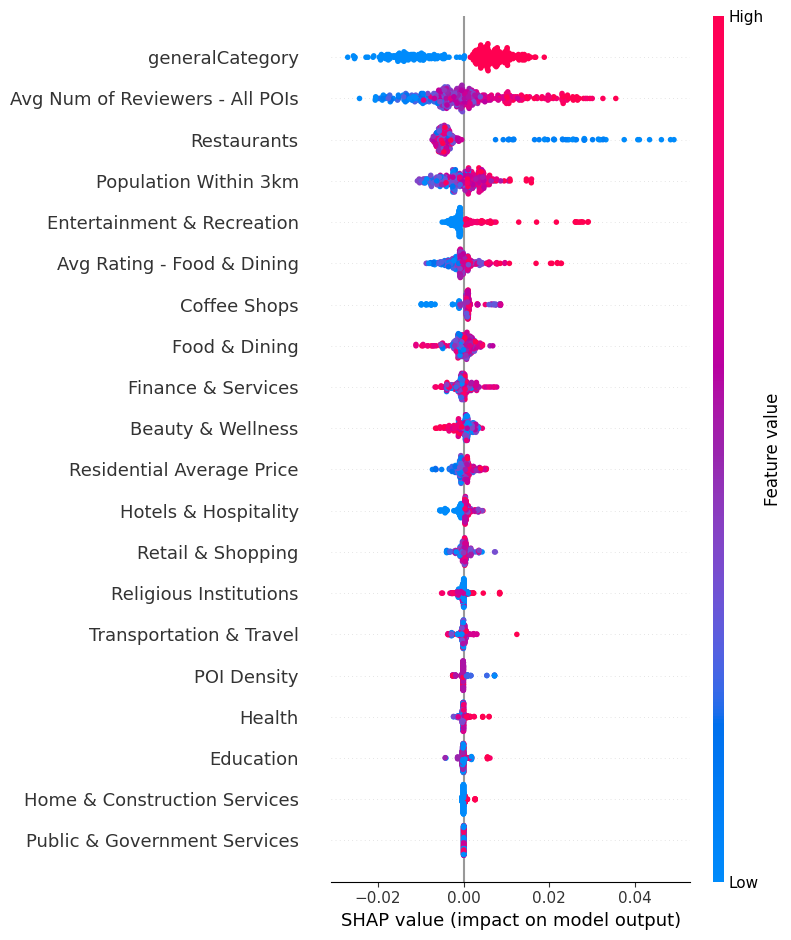

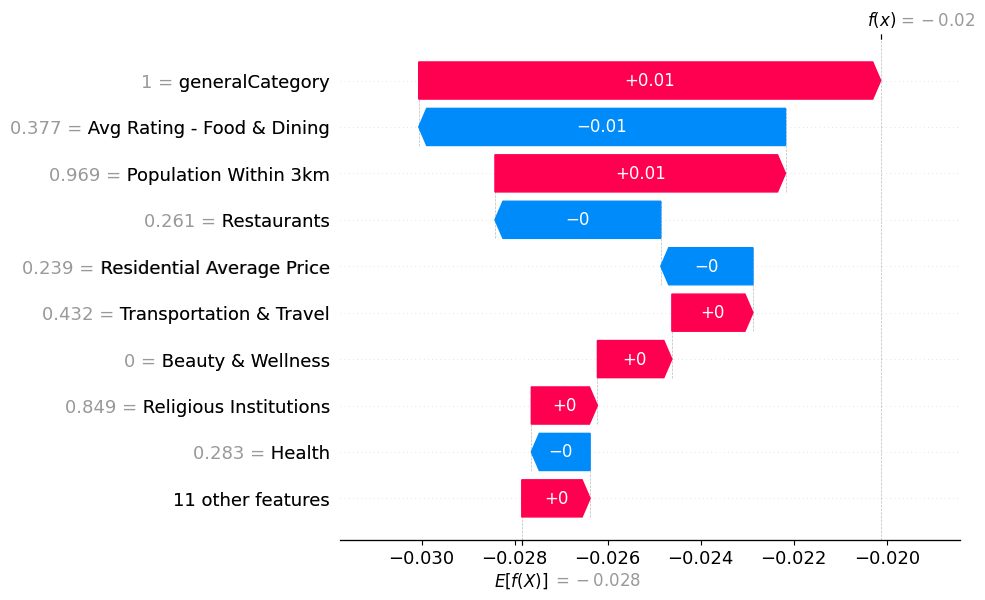

In [224]:
import shap
import matplotlib.pyplot as plt

# Use all test samples — be careful of memory use!
X_test_df = pd.DataFrame(X_test, columns=feature_cols)

explainer = shap.Explainer(model)

print("Calculating SHAP values for all test samples...")
shap_values = explainer(X_test_df)

# Summary plot: global feature importance
shap.summary_plot(shap_values, features=X_test_df, feature_names=feature_cols)

# Waterfall plot for the first instance
shap.plots.waterfall(shap_values[0])


In [226]:
import pandas as pd
import numpy as np

# Get the base values and SHAP values matrix
shap_values_matrix = shap_values.values  # shape: (n_samples, n_features)

# Compute mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_values_matrix).mean(axis=0)

# Create DataFrame of feature importances
shap_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

print(shap_importance_df)


                            feature  mean_abs_shap
0                   generalCategory       0.009231
1   Avg Num of Reviewers - All POIs       0.008576
2                       Restaurants       0.007018
3             Population Within 3km       0.003703
4        Entertainment & Recreation       0.002636
5        Avg Rating - Food & Dining       0.002544
6                      Coffee Shops       0.001761
7                     Food & Dining       0.001630
8                Finance & Services       0.001297
9                 Beauty & Wellness       0.001292
10        Residential Average Price       0.001268
11             Hotels & Hospitality       0.001044
12                Retail & Shopping       0.000747
13           Religious Institutions       0.000694
14          Transportation & Travel       0.000561
15                      POI Density       0.000460
16                           Health       0.000414
17                        Education       0.000394
18     Home & Construction Serv

### Recursive Feature Elimination with Cross-Validation (RFECV) 

In [215]:
import pandas as pd
import numpy as np
from sklearn.metrics import ndcg_score
import lightgbm as lgb

def compute_nsd(true_labels, pred_labels, k=10):
    true_top = set(np.argsort(true_labels)[::-1][:k])
    pred_top = set(np.argsort(pred_labels)[::-1][:k])
    return len(true_top.symmetric_difference(pred_top)) / (2 * k)

feature_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
feature_cols = [col for col in feature_cols if col != 'Number of Reviewers']

# 6. Hyper-param + feature-count search
param_grid = {
    'num_leaves': [15, 31, 63],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 5, 10, 15],
    'min_data_in_leaf': [5, 10, 20],
    'min_gain_to_split': [0.1, 0.5, 1.0],
}
feature_counts = [11, 9, 7, 5]

best_score = -np.inf
best_params = None
best_k = None
best_features = None
best_model = None

scores_per_k = {k: {'score': -np.inf, 'params': None, 'features': None} for k in feature_counts}

for leaves in param_grid['num_leaves']:
    for lr in param_grid['learning_rate']:
        params = {
            'objective': 'lambdarank',
            'metric': 'ndcg',
            'ndcg_eval_at': [10],
            'boosting_type': 'gbdt',
            'num_leaves': leaves,
            'learning_rate': lr,
            'verbosity': -1,
            'seed': 42
        }

        # 6.1 Train on all features
        dtrain = lgb.Dataset(X_train, label=y_train_rel, group=train_groups)
        dval = lgb.Dataset(X_val, label=y_val_rel, group=val_groups)
        model = lgb.train(
            params, train_set=dtrain, valid_sets=[dval],
            num_boost_round=100, callbacks=[lgb.early_stopping(10)]
        )

        # 6.2 Rank features by gain
        gains = model.feature_importance(importance_type='gain')
        idx_desc = np.argsort(gains)[::-1]

        for k in feature_counts:
            sel_idx = idx_desc[:k]
            sel_feats = [feature_cols[i] for i in sel_idx]

            Xtr_k = X_train[:, sel_idx]
            Xvl_k = X_val[:, sel_idx]

            dtr_k = lgb.Dataset(Xtr_k, label=y_train_rel, group=train_groups)
            dvl_k = lgb.Dataset(Xvl_k, label=y_val_rel, group=val_groups)

            m_k = lgb.train(
                params, train_set=dtr_k, valid_sets=[dvl_k],
                num_boost_round=100, callbacks=[lgb.early_stopping(10)]
            )

            yv_k = m_k.predict(Xvl_k)
            ndcg_k = ndcg_score([y_val_rel], [yv_k], k=10)

            print(f"[L{leaves} LR{lr}  K{k}] → nDCG@10: {ndcg_k:.4f}")

            if ndcg_k > scores_per_k[k]['score']:
                scores_per_k[k] = {
                    'score': ndcg_k,
                    'params': params.copy(),
                    'features': sel_feats
                }

            if ndcg_k > best_score:
                best_score = ndcg_k
                best_params = params.copy()
                best_k = k
                best_features = sel_feats
                best_model = m_k

# Report best per feature-count
print("\nBest for each feature count:")
for k in feature_counts:
    print(f"Top-{k} → nDCG@10: {scores_per_k[k]['score']:.3f}")
    print(" Params:", scores_per_k[k]['params'])
    print(" Features:", scores_per_k[k]['features'])
    print("-------------------------------")

# Final evaluation on test
X_test_k = X_test[:, [feature_cols.index(f) for f in best_features]]
ytest_pred = best_model.predict(X_test_k)

print("Best Overall:")
print(" nDCG@10:", best_score)
print(" k:", best_k)
print(" params:", best_params)
print(" features:", best_features)

# Importance for best-k
gain_k = best_model.feature_importance(importance_type='gain')
imp_df = pd.DataFrame({
    'Feature': best_features,
    'Gain': gain_k
}).sort_values('Gain', ascending=False)

print("\nFeature Importance (Gain) on best-k:")
print(imp_df.to_string(index=False))


Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[11]	valid_0's ndcg@10: 0.294956
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[4]	valid_0's ndcg@10: 0.288639
[L15 LR0.01  K11] → nDCG@10: 0.6800
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[3]	valid_0's ndcg@10: 0.245515
[L15 LR0.01  K9] → nDCG@10: 0.6659
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[8]	valid_0's ndcg@10: 0.252262
[L15 LR0.01  K7] → nDCG@10: 0.7558
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[3]	valid_0's ndcg@10: 0.257155
[L15 LR0.01  K5] → nDCG@10: 0.6713
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[7]	valid_0's ndcg@10: 0.26512
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration

### Average 10 runs 

#### 11 Features

In [216]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.metrics import ndcg_score
import lightgbm as lgb

# Compute nSD@10
def compute_nsd(true_labels, pred_labels, k=10):
    true_top = set(np.argsort(true_labels)[::-1][:k])
    print(true_top)
    pred_top = set(np.argsort(pred_labels)[::-1][:k])
    return len(true_top.symmetric_difference(pred_top)) / (2 * k)

# 6. Parameters (manually defined)
params = {'objective': 'lambdarank', 'metric': 'ndcg', 'ndcg_eval_at': [10], 'boosting_type': 'gbdt', 'num_leaves': 31, 'learning_rate': 0.05, 'verbosity': -1, 'seed': 42}

# Selected features (this should be a list you provide)
selected_features =  ['Avg Num of Reviewers - All POIs', 'Restaurants', 'generalCategory', 'Coffee Shops', 'Avg Rating - Food & Dining', 'Transportation & Travel', 'Food & Dining', 'Population Within 3km', 'Education', 'Entertainment & Recreation', 'Retail & Shopping']

# Number of runs
num_runs = 10

# Store results for averaging
results_ndcg = []
results_nsd = []

for run in range(num_runs):
    print(f"Running iteration {run + 1}/{num_runs}")

    # 6.1 Train on selected features
    selected_idx = [feature_cols.index(f) for f in selected_features]
    X_train_selected = X_train[:, selected_idx]
    X_val_selected = X_val[:, selected_idx]
    X_test_selected = X_test[:, selected_idx]

    dtrain = lgb.Dataset(X_train_selected, label=y_train_rel, group=train_groups)
    dval = lgb.Dataset(X_val_selected, label=y_val_rel, group=val_groups)
    
    # 6.2 Train the model
    model = lgb.train(
        params, train_set=dtrain, valid_sets=[dval],
        num_boost_round=100, callbacks=[lgb.early_stopping(10)]
    )

    # Prediction on test set
    y_test_pred = model.predict(X_test_selected)
    ndcg_k = ndcg_score([y_test_rel], [y_test_pred], k=10)
    nsd_k = compute_nsd(y_test, y_test_pred, k=10)

    
    # Save results for averaging later
    results_ndcg.append(ndcg_k)
    results_nsd.append(nsd_k)

# Calculate the average nDCG and nSD over all runs
average_ndcg = np.mean(results_ndcg)
average_nsd = np.mean(results_nsd)

# Print the average nDCG and nSD over all runs
print(f"Average nDCG@10 over {num_runs} runs on the test set: {average_ndcg:.3f}")
print(f"Average nSD@10 over {num_runs} runs on the test set: {average_nsd:.3f}")




Running iteration 1/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[10]	valid_0's ndcg@10: 0.472183
{226, 291, 100, 5, 42, 366, 144, 81, 178, 184}
Running iteration 2/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[10]	valid_0's ndcg@10: 0.472183
{226, 291, 100, 5, 42, 366, 144, 81, 178, 184}
Running iteration 3/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[10]	valid_0's ndcg@10: 0.472183
{226, 291, 100, 5, 42, 366, 144, 81, 178, 184}
Running iteration 4/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[10]	valid_0's ndcg@10: 0.472183
{226, 291, 100, 5, 42, 366, 144, 81, 178, 184}
Running iteration 5/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[10]	valid_0's ndcg@10: 0.472183
{226, 291, 100, 5, 42, 366, 144, 81, 178, 184}
Runni

#### 9 Features

In [217]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.metrics import ndcg_score
import lightgbm as lgb

# Compute nSD@10
def compute_nsd(true_labels, pred_labels, k=10):
    true_top = set(np.argsort(true_labels)[::-1][:k])
    pred_top = set(np.argsort(pred_labels)[::-1][:k])
    return len(true_top.symmetric_difference(pred_top)) / (2 * k)

# 6. Parameters (manually defined)
params = {'objective': 'lambdarank', 'metric': 'ndcg', 'ndcg_eval_at': [10], 'boosting_type': 'gbdt', 'num_leaves': 15, 'learning_rate': 0.1, 'verbosity': -1, 'seed': 42}

# Selected features (this should be a list you provide)
selected_features = ['Avg Num of Reviewers - All POIs', 'generalCategory', 'Avg Rating - Food & Dining', 'Finance & Services', 'Restaurants', 'Population Within 3km', 'Transportation & Travel', 'Retail & Shopping', 'Food & Dining']

# Number of runs
num_runs = 10

# Store results for averaging
results_ndcg = []
results_nsd = []

for run in range(num_runs):
    print(f"Running iteration {run + 1}/{num_runs}")

    # 6.1 Train on selected features
    selected_idx = [feature_cols.index(f) for f in selected_features]
    X_train_selected = X_train[:, selected_idx]
    X_val_selected = X_val[:, selected_idx]
    X_test_selected = X_test[:, selected_idx]

    dtrain = lgb.Dataset(X_train_selected, label=y_train_rel, group=train_groups)
    dval = lgb.Dataset(X_val_selected, label=y_val_rel, group=val_groups)
    
    # 6.2 Train the model
    model = lgb.train(
        params, train_set=dtrain, valid_sets=[dval],
        num_boost_round=100, callbacks=[lgb.early_stopping(10)]
    )

    # Prediction on test set
    y_test_pred = model.predict(X_test_selected)
    ndcg_k = ndcg_score([y_test_rel], [y_test_pred], k=10)
    nsd_k = compute_nsd(y_test, y_test_pred, k=10)

    # Save results for averaging later
    results_ndcg.append(ndcg_k)
    results_nsd.append(nsd_k)

# Calculate the average nDCG and nSD over all runs
average_ndcg = np.mean(results_ndcg)
average_nsd = np.mean(results_nsd)

# Print the average nDCG and nSD over all runs
print(f"Average nDCG@10 over {num_runs} runs on the test set: {average_ndcg:.3f}")
print(f"Average nSD@10 over {num_runs} runs on the test set: {average_nsd:.3f}")


Running iteration 1/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[4]	valid_0's ndcg@10: 0.330731
Running iteration 2/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[4]	valid_0's ndcg@10: 0.330731
Running iteration 3/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[4]	valid_0's ndcg@10: 0.330731
Running iteration 4/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[4]	valid_0's ndcg@10: 0.330731
Running iteration 5/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[4]	valid_0's ndcg@10: 0.330731
Running iteration 6/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[4]	valid_0's ndcg@10: 0.330731
Running iteration 7/10
Training until validation scores don't improve for 10 rounds
Early stop

#### 7 Features

In [218]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.metrics import ndcg_score
import lightgbm as lgb

# Compute nSD@10
def compute_nsd(true_labels, pred_labels, k=10):
    true_top = set(np.argsort(true_labels)[::-1][:k])
    pred_top = set(np.argsort(pred_labels)[::-1][:k])
    return len(true_top.symmetric_difference(pred_top)) / (2 * k)

# 6. Parameters (manually defined)
params = {'objective': 'lambdarank', 'metric': 'ndcg', 'ndcg_eval_at': [10], 'boosting_type': 'gbdt', 'num_leaves': 15, 'learning_rate': 0.01, 'verbosity': -1, 'seed': 42}

# Selected features (this should be a list you provide)
selected_features = ['Restaurants', 'Avg Num of Reviewers - All POIs', 'Retail & Shopping', 'Avg Rating - Food & Dining', 'Entertainment & Recreation', 'generalCategory', 'Hotels & Hospitality']

num_runs = 10

# Store results for averaging
results_ndcg = []
results_nsd = []

for run in range(num_runs):
    print(f"Running iteration {run + 1}/{num_runs}")

    # 6.1 Train on selected features
    selected_idx = [feature_cols.index(f) for f in selected_features]
    X_train_selected = X_train[:, selected_idx]
    X_val_selected = X_val[:, selected_idx]
    X_test_selected = X_test[:, selected_idx]

    dtrain = lgb.Dataset(X_train_selected, label=y_train_rel, group=train_groups)
    dval = lgb.Dataset(X_val_selected, label=y_val_rel, group=val_groups)
    
    # 6.2 Train the model
    model = lgb.train(
        params, train_set=dtrain, valid_sets=[dval],
        num_boost_round=100, callbacks=[lgb.early_stopping(10)]
    )

    # Prediction on test set
    y_test_pred = model.predict(X_test_selected)
    ndcg_k = ndcg_score([y_test_rel], [y_test_pred], k=10)
    nsd_k = compute_nsd(y_test, y_test_pred, k=10)

    # Save results for averaging later
    results_ndcg.append(ndcg_k)
    results_nsd.append(nsd_k)

# Calculate the average nDCG and nSD over all runs
average_ndcg = np.mean(results_ndcg)
average_nsd = np.mean(results_nsd)

# Print the average nDCG and nSD over all runs
print(f"Average nDCG@10 over {num_runs} runs on the test set: {average_ndcg:.3f}")
print(f"Average nSD@10 over {num_runs} runs on the test set: {average_nsd:.3f}")


Running iteration 1/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[8]	valid_0's ndcg@10: 0.252262
Running iteration 2/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[8]	valid_0's ndcg@10: 0.252262
Running iteration 3/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[8]	valid_0's ndcg@10: 0.252262
Running iteration 4/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[8]	valid_0's ndcg@10: 0.252262
Running iteration 5/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[8]	valid_0's ndcg@10: 0.252262
Running iteration 6/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[8]	valid_0's ndcg@10: 0.252262
Running iteration 7/10
Training until validation scores don't improve for 10 rounds
Early stop

#### 5 Features

In [219]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.metrics import ndcg_score
import lightgbm as lgb

# Compute nSD@10
def compute_nsd(true_labels, pred_labels, k=10):
    true_top = set(np.argsort(true_labels)[::-1][:k])
    pred_top = set(np.argsort(pred_labels)[::-1][:k])
    return len(true_top.symmetric_difference(pred_top)) / (2 * k)

# 6. Parameters (manually defined)
params = {'objective': 'lambdarank', 'metric': 'ndcg', 'ndcg_eval_at': [10], 'boosting_type': 'gbdt', 'num_leaves': 31, 'learning_rate': 0.1, 'verbosity': -1, 'seed': 42}

# Selected features (this should be a list you provide)
selected_features = ['generalCategory', 'Avg Rating - Food & Dining', 'Avg Num of Reviewers - All POIs', 'Population Within 3km', 'Restaurants']

# Number of runs
num_runs = 10

# Store results for averaging
results_ndcg = []
results_nsd = []

for run in range(num_runs):
    print(f"Running iteration {run + 1}/{num_runs}")

    # 6.1 Train on selected features
    selected_idx = [feature_cols.index(f) for f in selected_features]
    X_train_selected = X_train[:, selected_idx]
    X_val_selected = X_val[:, selected_idx]
    X_test_selected = X_test[:, selected_idx]

    dtrain = lgb.Dataset(X_train_selected, label=y_train_rel, group=train_groups)
    dval = lgb.Dataset(X_val_selected, label=y_val_rel, group=val_groups)
    
    # 6.2 Train the model
    model = lgb.train(
        params, train_set=dtrain, valid_sets=[dval],
        num_boost_round=100, callbacks=[lgb.early_stopping(10)]
    )

    # Prediction on test set
    y_test_pred = model.predict(X_test_selected)
    ndcg_k = ndcg_score([y_test_rel], [y_test_pred], k=10)
    nsd_k = compute_nsd(y_test, y_test_pred, k=10)

    # Save results for averaging later
    results_ndcg.append(ndcg_k)
    results_nsd.append(nsd_k)

# Calculate the average nDCG and nSD over all runs
average_ndcg = np.mean(results_ndcg)
average_nsd = np.mean(results_nsd)

# Print the average nDCG and nSD over all runs
print(f"Average nDCG@10 over {num_runs} runs on the test set: {average_ndcg:.3f}")
print(f"Average nSD@10 over {num_runs} runs on the test set: {average_nsd:.3f}")


Running iteration 1/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[11]	valid_0's ndcg@10: 0.407908
Running iteration 2/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[11]	valid_0's ndcg@10: 0.407908
Running iteration 3/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[11]	valid_0's ndcg@10: 0.407908
Running iteration 4/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[11]	valid_0's ndcg@10: 0.407908
Running iteration 5/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[11]	valid_0's ndcg@10: 0.407908
Running iteration 6/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[11]	valid_0's ndcg@10: 0.407908
Running iteration 7/10
Training until validation scores don't improve for 10 rounds
Earl